<a href="https://colab.research.google.com/github/saniya232/NASSCOM./blob/main/U6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)
print('Setup complete. NumPy', np.__version__)



Setup complete. NumPy 2.1.3


In [3]:
rolls = np.random.randint(1, 7, size=100_000)   # 100k dice rolls

p_even = (rolls % 2 == 0).mean()       # P(even)
p_gt4  = (rolls > 4).mean()            # P(roll > 4)
print('P(even) ~', round(p_even, 3), ' (true 0.5)')
print('P(>4)   ~', round(p_gt4, 3),  ' (true 0.333)')


P(even) ~ 0.502  (true 0.5)
P(>4)   ~ 0.334  (true 0.333)


In [4]:
p_1 = (rolls == 1).mean()
p_2 = (rolls == 2).mean()
p_1_or_2 = (np.isin(rolls, [1, 2])).mean()
print('P(1) + P(2) =', round(p_1 + p_2, 3))
print('P(1 or 2)   =', round(p_1_or_2, 3), ' -> they match')

P(1) + P(2) = 0.334
P(1 or 2)   = 0.334  -> they match


In [5]:
import random

n = 10000

zero_heads = 0
one_head = 0
two_heads = 0

for i in range(n):
    coin1 = random.choice(["H", "T"])
    coin2 = random.choice(["H", "T"])

    heads = 0

    if coin1 == "H":
        heads += 1
    if coin2 == "H":
        heads += 1

    if heads == 0:
        zero_heads += 1
    elif heads == 1:
        one_head += 1
    else:
        two_heads += 1

# Probabilities
p_both_heads = two_heads / n
p_at_least_one_head = (one_head + two_heads) / n

print("P(both heads) =", p_both_heads)
print("P(at least one head) =", p_at_least_one_head)

# Check addition idea
total = (zero_heads + one_head + two_heads) / n

print("P(0 heads) =", zero_heads / n)
print("P(1 head) =", one_head / n)
print("P(2 heads) =", two_heads / n)
print("Sum of probabilities =", total)

P(both heads) = 0.2499
P(at least one head) = 0.7517
P(0 heads) = 0.2483
P(1 head) = 0.5018
P(2 heads) = 0.2499
Sum of probabilities = 1.0


In [7]:
flips = np.random.randint(0, 2, size=(100_000, 2))
heads = flips.sum(axis=1)


In [8]:
rolls = np.random.randint(1, 7, size=100_000)
even = rolls[rolls % 2 == 0]
p_6_given_even = (even == 6).mean()
print('P(6 | even) ~', round(p_6_given_even, 3), ' (true 1/3)')


P(6 | even) ~ 0.334  (true 1/3)


In [9]:
A = rolls > 3
B = rolls % 2 == 0
p_A        = A.mean()
p_A_given_B = A[B].mean()
print('P(A)      =', round(p_A, 3))
print('P(A | B)  =', round(p_A_given_B, 3))
print('Independent?', np.isclose(p_A, p_A_given_B, atol=0.02))

P(A)      = 0.502
P(A | B)  = 0.667
Independent? False


In [10]:
import random

n = 10000

odd = 0
less_than_4 = 0
odd_and_less_than_4 = 0

for i in range(n):
    roll = random.randint(1, 6)

    if roll % 2 != 0:
        odd += 1

    if roll < 4:
        less_than_4 += 1

    if roll % 2 != 0 and roll < 4:
        odd_and_less_than_4 += 1

# 1. P(odd | roll < 4)
p_odd_given_less4 = odd_and_less_than_4 / less_than_4

# 2. P(roll < 4)
p_less4 = less_than_4 / n

# P(odd)
p_odd = odd / n

print("P(odd | roll < 4) =", p_odd_given_less4)
print("P(roll < 4) =", p_less4)
print("P(odd) =", p_odd)

# 3. Check independence
if abs(p_odd_given_less4 - p_odd) < 0.02:
    print("Events are approximately independent")
else:
    print("Events are not independent")


P(odd | roll < 4) = 0.6680605336519315
P(roll < 4) = 0.5022
P(odd) = 0.4998
Events are not independent


In [11]:
olls = np.random.randint(1, 7, size=100_000)


In [12]:
p_disease   = 0.01
p_pos_given_D  = 0.99
p_pos_given_nD = 0.01
p_pos = p_pos_given_D * p_disease + p_pos_given_nD * (1 - p_disease)
p_D_given_pos = (p_pos_given_D * p_disease) / p_pos
print('P(sick | positive test) =', round(p_D_given_pos, 3))
print('-> only ~50%, because the disease is rare (base-rate effect)')


P(sick | positive test) = 0.5
-> only ~50%, because the disease is rare (base-rate effect)


In [13]:

N = 1_000_000
has_disease = np.random.rand(N) < p_disease
tests_pos = np.where(has_disease,
                     np.random.rand(N) < p_pos_given_D,
                     np.random.rand(N) < p_pos_given_nD)

among_positive = has_disease[tests_pos]
print('Simulated P(sick | positive) =', round(among_positive.mean(), 3))



Simulated P(sick | positive) = 0.495


In [14]:

p_spam = 0.30
p_free_given_spam = 0.80
p_free_given_not_spam = 0.1
print("Prior =", p_spam)
print("Likelihood =", p_free_given_spam)
print("False Positive Rate =", p_free_given_not_spam)
p_not_spam = 1 - p_spam

p_free = (p_free_given_spam * p_spam) + \
         (p_free_given_not_spam * p_not_spam)

print("P(free) =", p_free)
p_spam_given_free = (p_free_given_spam * p_spam) / p_free

print("P(spam | free) =", p_spam_given_free)
print("Percentage =", p_spam_given_free * 100, "%")

Prior = 0.3
Likelihood = 0.8
False Positive Rate = 0.1
P(free) = 0.31
P(spam | free) = 0.7741935483870968
Percentage = 77.41935483870968 %


In [15]:
p_spam = 0.20
p_free_given_spam = 0.60
p_free_given_ham  = 0.05


In [16]:
bern = stats.bernoulli(p=0.3).rvs(size=10_000)
print('Bernoulli(0.3) mean ~', round(bern.mean(), 3), '(true 0.3)')

# Poisson: count of events per interval, rate lambda
pois = stats.poisson(mu=4).rvs(size=10_000)
print('Poisson(4) mean ~', round(pois.mean(), 3), '(true 4)')


Bernoulli(0.3) mean ~ 0.297 (true 0.3)
Poisson(4) mean ~ 4.005 (true 4)


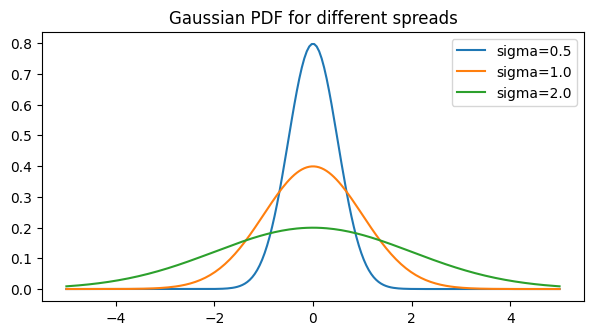

In [17]:
x = np.linspace(-5, 5, 200)
fig, ax = plt.subplots(figsize=(7, 3.5))
for sigma in [0.5, 1.0, 2.0]:
    ax.plot(x, stats.norm(0, sigma).pdf(x), label=f'sigma={sigma}')
ax.set_title('Gaussian PDF for different spreads'); ax.legend(); plt.show()

Sample Mean = 1.9641


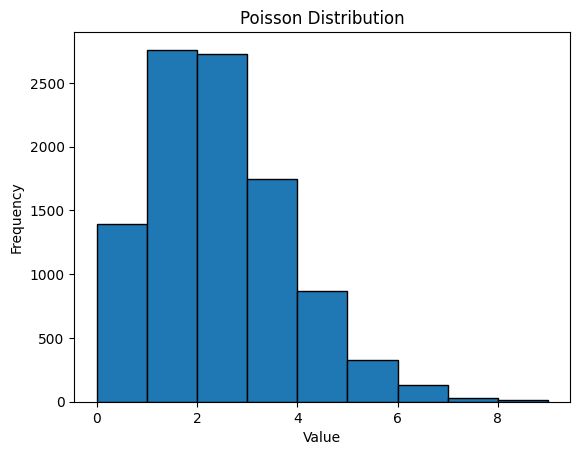

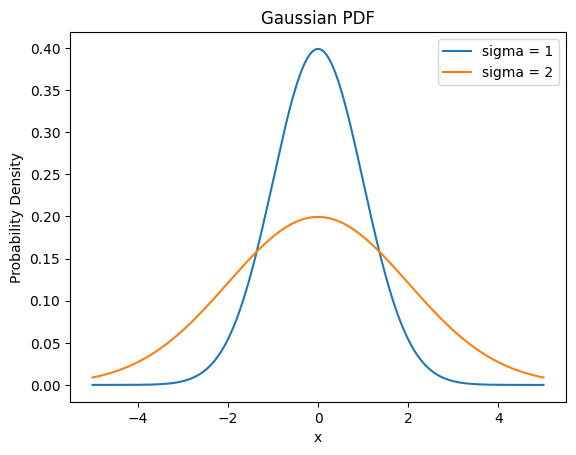

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 1. Draw 10,000 samples from Poisson distribution
samples = np.random.poisson(2, 10000)

# Print sample mean
print("Sample Mean =", np.mean(samples))


# 2. Plot histogram
plt.hist(samples, bins=range(0, 10), edgecolor="black")
plt.title("Poisson Distribution")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()


# 3. Gaussian PDF with two different sigma values
x = np.linspace(-5, 5, 1000)

mu = 0
sigma1 = 1
sigma2 = 2

pdf1 = norm.pdf(x, mu, sigma1)
pdf2 = norm.pdf(x, mu, sigma2)

plt.plot(x, pdf1, label="sigma = 1")
plt.plot(x, pdf2, label="sigma = 2")

plt.title("Gaussian PDF")
plt.xlabel("x")
plt.ylabel("Probability Density")
plt.legend()
plt.show()

In [20]:
from scipy.stats import entropy

fair   = [0.5, 0.5]      # a fair coin: maximum uncertainty
biased = [0.9, 0.1]      # a biased coin: more predictable
certain= [1.0, 0.0]      # no uncertainty at all

# base=2 gives entropy in BITS
print('Entropy fair coin   :', round(entropy(fair, base=2), 3), 'bits')
print('Entropy biased coin :', round(entropy(biased, base=2), 3), 'bits')
print('Entropy certain     :', round(entropy(certain, base=2), 3), 'bits')



Entropy fair coin   : 1.0 bits
Entropy biased coin : 0.469 bits
Entropy certain     : 0.0 bits


In [21]:
P = np.array([0.5, 0.5])
Q = np.array([0.9, 0.1])

# scipy's entropy(P, Q) computes the KL divergence D(P || Q)
print('D(P || Q) =', round(entropy(P, Q, base=2), 3), 'bits')
print('D(P || P) =', round(entropy(P, P, base=2), 3), '-> zero (identical)')
print('Note: D(P||Q) != D(Q||P)  ->', round(entropy(Q, P, base=2), 3), '(not symmetric)')

D(P || Q) = 0.737 bits
D(P || P) = 0.0 -> zero (identical)
Note: D(P||Q) != D(Q||P)  -> 0.531 (not symmetric)


In [22]:

from sklearn.feature_selection import mutual_info_classif
from sklearn.datasets import load_iris

iris = load_iris()
mi = mutual_info_classif(iris.data, iris.target, random_state=0)
for name, score in sorted(zip(iris.feature_names, mi), key=lambda t: -t[1]):
    print(f'{score:.3f}  {name}')
print('-> higher MI = the feature tells us more about the class')


0.990  petal length (cm)
0.975  petal width (cm)
0.474  sepal length (cm)
0.286  sepal width (cm)
-> higher MI = the feature tells us more about the class


In [23]:
import math

# Fair 4-sided die
H4 = math.log2(4)

# Fair 6-sided die
H6 = math.log2(6)

print("Entropy of 4-sided die =", H4, "bits")
print("Entropy of 6-sided die =", H6, "bits")

if H6 > H4:
    print("6-sided die is more uncertain")
else:
    print("4-sided die is more uncertain")

Entropy of 4-sided die = 2.0 bits
Entropy of 6-sided die = 2.584962500721156 bits
6-sided die is more uncertain
